In [32]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
import math
import matplotlib.pyplot as plt
import numpy as np
from omegaconf import OmegaConf
import os
import pandas as pd
import torch
from torch.autograd.functional import jacobian as autograd_jacobian
from torch.utils.data import RandomSampler, DataLoader
from tqdm.auto import tqdm
import wandb

from JacobianODE.jacobians import (
    load_config,
    initialize_config,
    seed_everything,
    make_trajectories,
    postprocess_data,
    create_dataloaders,
    load_run,
    load_checkpoint,
    select_best_model,
    DiagnosticMetrics,
)
from JacobianODE.jacobians.metrics import r2_score, normalized_mse as nmse_fn, mase
from JacobianODE.jacobians.tuning import select_from_wandb_runs
from JacobianODE.jacobians.lightning_base import loop_closure
from JacobianODE.models.latent_jacobian import LitLatentJacobianODE
from JacobianODE.fnn import loss_false, loss_amplification

torch.set_float32_matmul_precision('high')

## 1. Settings

Specify the W&B project, optional group, and save directory for checkpoints.

In [34]:
# ================================================================
# W&B project and group (EDIT THESE)
# ================================================================
WANDB_ENTITY  = "JacobianODE"

# spline coupling w/ partial obs (N100), vae KLD KLN LC ES sweep
# WANDB_PROJECT = "Lorenz_IND0_N100_D1_NormTrue_T3__spline_coupling__JacobianODE"
# WANDB_GROUP = "sweep_from_scratch_spline_coupling_lc_9vals__klNNone_1.0__klD0_0.0001_0.001_0.01_0.1_1__te0.0_enc_warmup_5_vaetrue"

# WANDB_PROJECT = "Lorenz_IND0_N100_D1_NormTrue_T7__spline_coupling__JacobianODE"
# WANDB_GROUP = None

WANDB_PROJECT = "WMTask_INDall_N1_D1_NormTrue_T128__JacobianODE"
# WANDB_GROUP = None
# WANDB_GROUP = "spline_coupling__sweep_lc_x_kl_dyn_vae_sample_all_losses"
# WANDB_GROUP = "mlp_diffeo__sweep_lc_x_kl_dyn_vae_sample_all_losses"
# WANDB_GROUP = "spline_coupling__geometric_noise__sweep_lc_x_kl_dyn"
# WANDB_GROUP = "spline_coupling__geometric_noise__sweep_lc_x_kl_dyn_30step_cleantarget"
WANDB_GROUP = "spline_coupling__sweep_lc_x_kl_dyn_30step_cleantarget"

# WANDB_PROJECT = "Lorenz_IND[0]_N25_D1_NormTrue_T3__JacobianODE"
# WANDB_GROUP = "spline_coupling__geometric_noise__sweep_lc_x_kl_dyn_30step_cleantarget"

WANDB_PROJECT_PATH = f"{WANDB_ENTITY}/{WANDB_PROJECT}"

# ================================================================
# Checkpoint save directory
# ================================================================
SAVE_DIR = "/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/latent_jac_runs"

# ================================================================
# Known true Lyapunov exponents (for Lorenz: sigma=10, rho=28, beta=8/3)
# Set to None for wmtask — will be overridden after loading first run (Section 3)
# ================================================================
TRUE_LYAPUNOV = [0.91, 0.0, -14.57]  # None for wmtask (overridden from config)

print(f"W&B project: {WANDB_PROJECT_PATH}")
print(f"W&B group:   {WANDB_GROUP}")
print(f"Save dir:    {SAVE_DIR}")

W&B project: JacobianODE/WMTask_INDall_N1_D1_NormTrue_T128__JacobianODE
W&B group:   spline_coupling__sweep_lc_x_kl_dyn_30step_cleantarget
Save dir:    /orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/latent_jac_runs


## 2. Collect W&B Runs

In [35]:
api = wandb.Api()
try:
    run_filters = {'group': WANDB_GROUP} if WANDB_GROUP else None
    all_runs = api.runs(WANDB_PROJECT_PATH, filters=run_filters)
    msg = f'Found {len(all_runs)} total runs in {WANDB_PROJECT_PATH}'
    if WANDB_GROUP:
        msg = msg + f' (group={WANDB_GROUP})'
    print(msg)
except Exception as e:
    print(f'Could not query project: {e}')
    all_runs = []

Found 61 total runs in JacobianODE/WMTask_INDall_N1_D1_NormTrue_T128__JacobianODE (group=spline_coupling__sweep_lc_x_kl_dyn_30step_cleantarget)


## 3. Filter Finished Runs

In [36]:
# Keep only runs that finished successfully (exclude running, crashed, etc.)
finished_runs = [r for r in all_runs if r.state == "finished"]
print(f"Finished runs: {len(finished_runs)} / {len(all_runs)}")

Finished runs: 52 / 61


## 4. Extract Config & Simulate Early Stopping with Patience = 2

For each finished run with `early_stopping_patience = 5`:
- Extract hyperparameters from config
- Pull the full `mean val loss` history
- Replay the `PercentEarlyStopping` logic with patience = 2 to find where training *would have* stopped
- Record both the actual best val loss (patience=5) and the counterfactual best val loss (patience=2)

In [37]:
def simulate_percent_early_stopping(val_losses, patience, percent_thresh=0.01, min_epochs=0):
    """Replay PercentEarlyStopping logic on a list of per-epoch val losses.

    Returns (stop_epoch, best_val_loss_up_to_stop) where stop_epoch is the
    0-indexed epoch at which training would have stopped, or len(val_losses)-1
    if it would never have triggered.
    """
    prev_loss = None
    wait_count = 0
    stop_epoch = None
    for epoch, loss in enumerate(val_losses):
        if epoch < min_epochs:
            prev_loss = loss  # Skip early stopping check until min_epochs
            continue
        if not math.isfinite(loss):  # still update baseline
            wait_count = wait_count + 1
            if wait_count >= patience:
                stop_epoch = epoch  # Handle NaN/Inf
                break
            continue
        if prev_loss is None:
            prev_loss = loss
            continue
        if not math.isfinite(prev_loss):
            prev_loss = loss
            wait_count = 0
            continue
        if prev_loss > loss:
            percent_improvement = (prev_loss - loss) / prev_loss
            if percent_improvement < percent_thresh:  # If prev_loss was NaN/Inf, reset baseline
                wait_count = wait_count + 1
            else:
                wait_count = 0
        else:
            wait_count = wait_count + 1
        prev_loss = loss  # Check percent improvement
        if wait_count >= patience:
            stop_epoch = epoch
            break
    if stop_epoch is None:
        stop_epoch = len(val_losses) - 1
    valid_losses = [l for l in val_losses[:stop_epoch + 1] if math.isfinite(l)]
    best_val_loss = min(valid_losses) if valid_losses else float('nan')
    return (stop_epoch, best_val_loss)  # Best val loss up to the stop epoch (model checkpoint saves best)

In [38]:
records = []
for run in tqdm(finished_runs, desc='Processing runs'):
    cfg = run.config
    es_cfg = cfg.get('training', {}).get('early_stopping', {})
    es_patience = es_cfg.get('early_stopping_patience', None)
    if es_patience != 5:  # Extract early stopping patience
        continue
    lightning_cfg = cfg.get('training', {}).get('lightning', {})
    loop_closure_weight = lightning_cfg.get('loop_closure_weight', None)
    kl_dyn_weight = lightning_cfg.get('kl_dyn_weight', None)  # Only keep runs with patience = 5
    kl_null_weight = lightning_cfg.get('kl_null_weight', None)
    if kl_null_weight is not None:
        try:
            if not math.isfinite(float(kl_null_weight)):  # Extract hyperparameters
                kl_null_weight = kl_dyn_weight
        except (ValueError, TypeError):
            kl_null_weight = kl_dyn_weight
    else:
        kl_null_weight = kl_dyn_weight
    model_cfg = cfg.get('model', {})  # Normalize null/NaN kl_null_weight to kl_dyn_weight
    kl_warmup_epochs = model_cfg.get('kl_warmup_epochs', None)
    percent_thresh = es_cfg.get('percent_thresh', 0.01)
    min_epochs = es_cfg.get('min_epochs', 0)
    _history = list(run.scan_history(keys=['mean val loss', 'trajectory val_loss', 'val/loop_closure_loss', '_step'], page_size=10000))
    val_losses = []
    lc_losses = []
    traj_val_losses = []
    for _row in _history:
        v = _row.get('mean val loss')
        lc = _row.get('val/loop_closure_loss')
        tv = _row.get('trajectory val_loss')
        if v is not None:
            try:
                val_losses.append(float(v))
                lc_losses.append(float(lc) if lc is not None else float('nan'))
                traj_val_losses.append(float(tv) if tv is not None else float('nan'))  # Pull full history for mean val loss, trajectory val_loss, and val/loop_closure_loss together
            except (ValueError, TypeError):
                continue
    if len(val_losses) == 0:
        continue
    actual_stop_epoch = len(val_losses) - 1
    valid_all = [(_i, l) for _i, l in enumerate(val_losses) if math.isfinite(l)]
    best_epoch_p5 = min(valid_all, key=lambda x: x[1])[0] if valid_all else 0
    best_val_loss_p5 = val_losses[best_epoch_p5] if valid_all else float('nan')
    lc_loss_at_best_p5 = lc_losses[best_epoch_p5] if best_epoch_p5 < len(lc_losses) else float('nan')
    stop_epoch_p2, best_val_loss_p2 = simulate_percent_early_stopping(val_losses, patience=2, percent_thresh=percent_thresh, min_epochs=min_epochs)
    valid_p2 = [(_i, l) for _i, l in enumerate(val_losses[:stop_epoch_p2 + 1]) if math.isfinite(l)]
    best_epoch_p2 = min(valid_p2, key=lambda x: x[1])[0] if valid_p2 else 0
    lc_loss_at_best_p2 = lc_losses[best_epoch_p2] if best_epoch_p2 < len(lc_losses) else float('nan')
    finite_losses = [(_i, l) for _i, l in enumerate(val_losses) if math.isfinite(l)]
    if len(finite_losses) >= 2:
        fl_vals = [l for _, l in finite_losses]
        diffs = [abs(fl_vals[_i + 1] - fl_vals[_i]) for _i in range(len(fl_vals) - 1)]
        signed_diffs = [fl_vals[_i + 1] - fl_vals[_i] for _i in range(len(fl_vals) - 1)]
        total_variation = sum(diffs)
        net_improvement = fl_vals[0] - min(fl_vals)
        norm_total_variation = total_variation / net_improvement if net_improvement > 1e-12 else float('nan')
        frac_non_improving = sum((1 for d in signed_diffs if d >= 0)) / len(signed_diffs)
        mean_loss = sum(fl_vals) / len(fl_vals)  # --- ES5: best checkpoint = argmin over all epochs ---
        mean_abs_change_norm = sum(diffs) / len(diffs) / mean_loss if mean_loss > 1e-12 else float('nan')
    else:
        norm_total_variation = float('nan')
        frac_non_improving = float('nan')
        mean_abs_change_norm = float('nan')
    records.append({'run_id': run.id, 'run_name': run.name, 'loop_closure_weight': loop_closure_weight, 'kl_dyn_weight': kl_dyn_weight, 'kl_null_weight': kl_null_weight, 'kl_warmup_epochs': kl_warmup_epochs, 'es_patience': es_patience, 'percent_thresh': percent_thresh, 'total_epochs': len(val_losses), 'stop_epoch_p5': actual_stop_epoch, 'best_epoch_p5': best_epoch_p5, 'best_val_loss_p5': best_val_loss_p5, 'lc_loss_at_best_p5': lc_loss_at_best_p5, 'stop_epoch_p2': stop_epoch_p2, 'best_epoch_p2': best_epoch_p2, 'best_val_loss_p2': best_val_loss_p2, 'lc_loss_at_best_p2': lc_loss_at_best_p2, 'traj_val_loss_history': traj_val_losses, 'norm_total_variation': norm_total_variation, 'frac_non_improving': frac_non_improving, 'mean_abs_change_norm': mean_abs_change_norm})
print(f'Collected {len(records)} runs with early_stopping_patience = 5')

Processing runs:   0%|          | 0/52 [00:00<?, ?it/s]

Collected 52 runs with early_stopping_patience = 5


## 5. Results DataFrame

In [39]:
df = pd.DataFrame(records)

# Add derived columns
df["epochs_saved"] = df["stop_epoch_p5"] - df["stop_epoch_p2"]
df["val_loss_diff"] = df["best_val_loss_p2"] - df["best_val_loss_p5"]
df["val_loss_pct_diff"] = (df["val_loss_diff"] / df["best_val_loss_p5"]) * 100

print(f"Shape: {df.shape}")
df

Shape: (52, 24)


,run_id,run_name,loop_closure_weight,kl_dyn_weight,kl_null_weight,kl_warmup_epochs,es_patience,percent_thresh,total_epochs,stop_epoch_p5,...,best_epoch_p2,best_val_loss_p2,lc_loss_at_best_p2,traj_val_loss_history,norm_total_variation,frac_non_improving,mean_abs_change_norm,epochs_saved,val_loss_diff,val_loss_pct_diff
0,3faysy6m,"MLP__hidden_dim_[256, 1024, 2048, 2048]__num_l...",0.000000,0.001000,0.001000,0,5,0.01,109,108,...,28,0.014068,13.160727,"[4.746030330657959, 4.424900054931641, 4.14874...",1.028984,0.444444,0.214313,78,0.009284,194.081013
1,lhlqgosq,"MLP__hidden_dim_[256, 1024, 2048, 2048]__num_l...",0.000000,0.000000,0.000000,0,5,0.01,105,104,...,41,0.011905,6.120593,"[5.338245391845703, 5.874962329864502, 6.03087...",1.347835,0.317308,0.228144,59,0.006759,131.345154
2,1hl94h34,"MLP__hidden_dim_[256, 1024, 2048, 2048]__num_l...",0.000000,0.000100,0.000100,0,5,0.01,109,108,...,15,0.032265,14.325184,"[5.276934623718262, 5.6143317222595215, 5.5018...",1.157752,0.462963,0.209428,91,0.027191,535.868334
3,4gi2m7hl,"MLP__hidden_dim_[256, 1024, 2048, 2048]__num_l...",0.000000,0.000001,0.000001,0,5,0.01,107,106,...,19,0.027541,7.837121,"[5.337649345397949, 5.872041702270508, 6.02376...",1.334329,0.367925,0.225838,85,0.022517,448.171362
4,dvirdh5p,"MLP__hidden_dim_[256, 1024, 2048, 2048]__num_l...",0.000000,0.100000,0.100000,0,5,0.01,68,67,...,12,0.052465,198.070938,"[3.1033051013946533, 2.682131767272949, 2.6245...",1.357107,0.462687,0.264809,53,0.045003,603.094521
5,gw47jqdi,"MLP__hidden_dim_[256, 1024, 2048, 2048]__num_l...",0.000000,0.000010,0.000010,0,5,0.01,107,106,...,35,0.013612,6.260462,"[5.332135200500488, 5.845479965209961, 5.95916...",1.327455,0.424528,0.226926,69,0.008561,169.518398
6,mfxypvv4,"MLP__hidden_dim_[256, 1024, 2048, 2048]__num_l...",0.000000,0.010000,0.010000,0,5,0.01,71,70,...,10,0.032001,18.467270,"[3.50193452835083, 2.859811782836914, 2.661355...",1.483851,0.457143,0.313058,58,0.026864,522.995284
7,sxj3tx2n,"MLP__hidden_dim_[256, 1024, 2048, 2048]__num_l...",0.000000,1.000000,1.000000,0,5,0.01,30,29,...,14,0.061617,400.178253,"[3.128859281539917, 2.770819902420044, 2.64760...",1.365881,0.360000,0.266758,13,0.030308,96.804373
8,eyv5emvs,"MLP__hidden_dim_[256, 1024, 2048, 2048]__num_l...",0.000001,0.000001,0.000001,0,5,0.01,68,67,...,21,0.024567,4.922202,"[5.337657928466797, 5.872073173522949, 6.02372...",1.349099,0.402985,0.231334,44,0.017104,229.167394
9,ij7nctt5,"MLP__hidden_dim_[256, 1024, 2048, 2048]__num_l...",0.000001,0.000010,0.000010,0,5,0.01,69,68,...,23,0.022135,4.598866,"[5.332158088684082, 5.845498561859131, 5.95921...",1.324609,0.397059,0.229207,43,0.014705,197.931212


## 6. Val Loss vs Hyperparameters (ES5 vs ES2)

After LC loss filter (threshold=1.732):
  ES5: 23 / 52 runs kept
  ES2: 28 / 52 runs kept


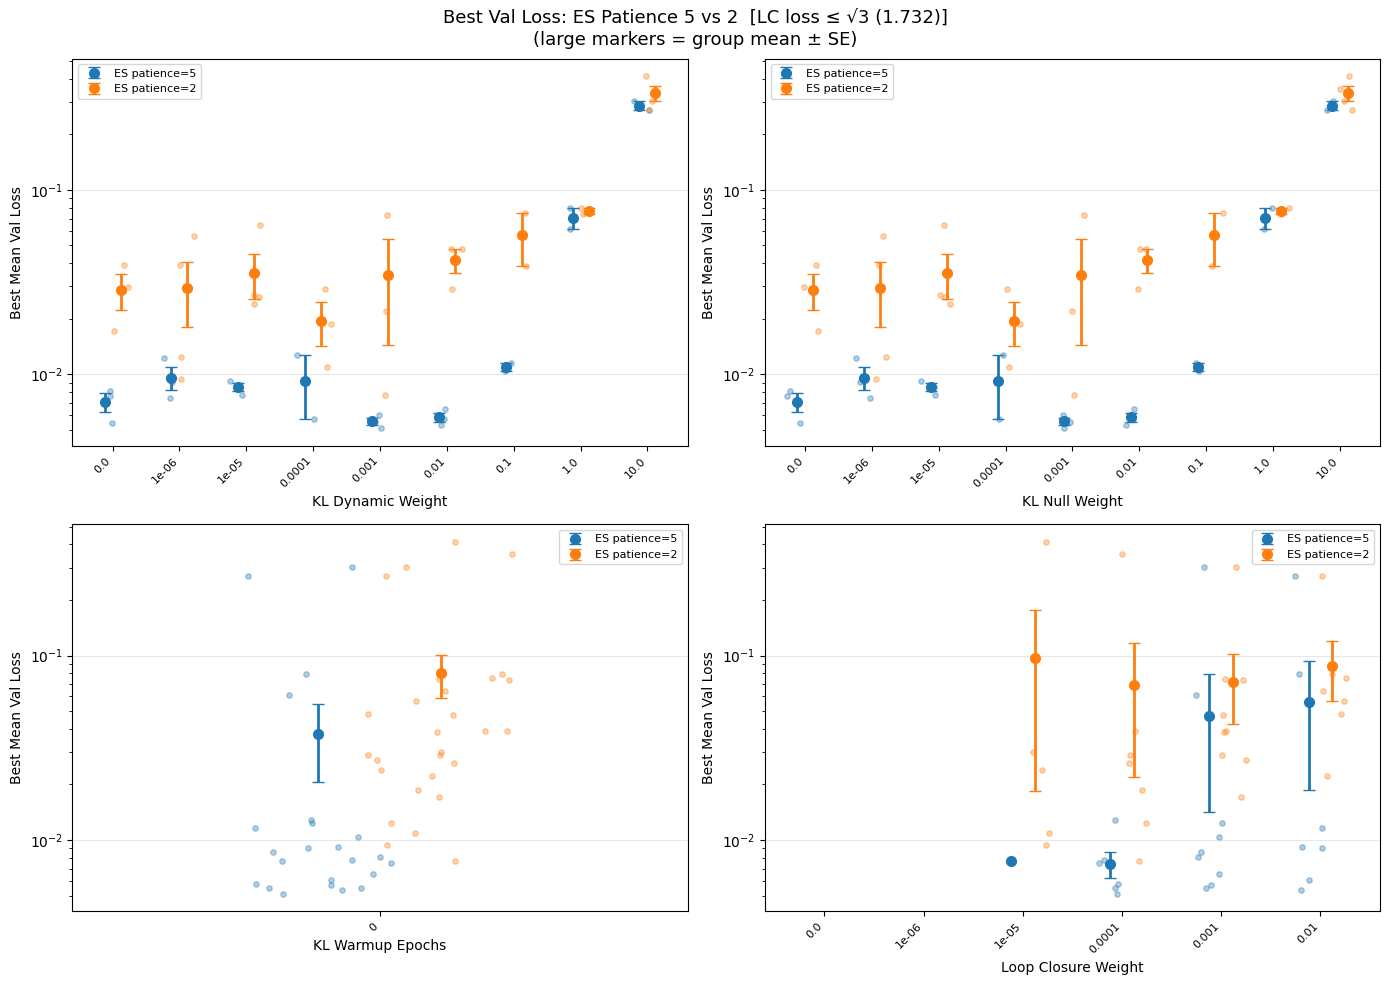

In [40]:
# ================================================================
# Filter: drop runs where val loop closure loss > sqrt(3)
# Applies the ES5 LC loss to the ES5 series and the ES2 LC loss to the ES2 series.
LC_LOSS_FILTER = True
LC_LOSS_THRESHOLD = math.sqrt(3)
df_p5 = df.copy()
df_p2 = df.copy()
if LC_LOSS_FILTER:
    df_p5 = df_p5[df_p5['lc_loss_at_best_p5'].apply(lambda x: math.isfinite(x) and x <= LC_LOSS_THRESHOLD)]
    df_p2 = df_p2[df_p2['lc_loss_at_best_p2'].apply(lambda x: math.isfinite(x) and x <= LC_LOSS_THRESHOLD)]
    print(f'After LC loss filter (threshold={LC_LOSS_THRESHOLD:.3f}):')
    print(f'  ES5: {len(df_p5)} / {len(df)} runs kept')
    print(f'  ES2: {len(df_p2)} / {len(df)} runs kept')
_fig, _axes = plt.subplots(2, 2, figsize=(14, 10))
_params = [('kl_dyn_weight', 'KL Dynamic Weight'), ('kl_null_weight', 'KL Null Weight'), ('kl_warmup_epochs', 'KL Warmup Epochs'), ('loop_closure_weight', 'Loop Closure Weight')]
rng = np.random.default_rng(42)
for _ax, (_col, _label) in zip(_axes.flat, _params):
    _categories = sorted(df[_col].unique())
    _cat_to_pos = {c: _i for _i, c in enumerate(_categories)}
    _n_cats = len(_categories)
    for _src_df, _offset, _loss_col, lc_col, _color, _es_label in [(df_p5, -0.12, 'best_val_loss_p5', 'lc_loss_at_best_p5', 'C0', 'ES patience=5'), (df_p2, 0.12, 'best_val_loss_p2', 'lc_loss_at_best_p2', 'C1', 'ES patience=2')]:
        _positions = np.array([_cat_to_pos[v] for v in _src_df[_col]])
        _jitter = rng.uniform(-0.15, 0.15, size=len(_src_df))
        _ax.scatter(_positions + _jitter + _offset, _src_df[_loss_col], alpha=0.35, s=15, color=_color, zorder=2)
        _first = True
        for _i, _cat in enumerate(_categories):
            _mask = _src_df[_col] == _cat
            _vals = _src_df.loc[_mask, _loss_col].dropna()
            if len(_vals) == 0:
                continue
            _mean = _vals.mean()
            _se = _vals.sem()
            _ax.errorbar(_i + _offset, _mean, yerr=_se, fmt='o', color=_color, markersize=7, capsize=4, linewidth=2, zorder=3, label=_es_label if _first else None)
            _first = False
    _ax.set_xticks(range(_n_cats))
    _ax.set_xticklabels([str(c) for c in _categories], rotation=45, ha='right', fontsize=8)
    _ax.set_xlim(-0.6, _n_cats - 0.4)
    _ax.set_xlabel(_label)
    _ax.set_ylabel('Best Mean Val Loss')
    _ax.set_yscale('log')
    _ax.legend(fontsize=8)
    _ax.grid(True, axis='y', alpha=0.3)  # Individual points
_filter_str = f'LC loss ≤ √3 ({LC_LOSS_THRESHOLD:.3f})' if LC_LOSS_FILTER else 'no LC loss filter'
_fig.suptitle(f'Best Val Loss: ES Patience 5 vs 2  [{_filter_str}]\n(large markers = group mean ± SE)', fontsize=13)
_fig.tight_layout()
plt.show()  # Group means ± SE

After kl_dyn_weight ≤ 0.001 + kl_null_weight ≤ 0.001 filter:
  ES5: 14 / 23 runs kept
  ES2: 17 / 28 runs kept

ES5 — mean val loss by kl_warmup_epochs:
  warmup=   0: mean=0.0079  n=14

ES2 — mean val loss by kl_warmup_epochs:
  warmup=   0: mean=0.0298  n=17


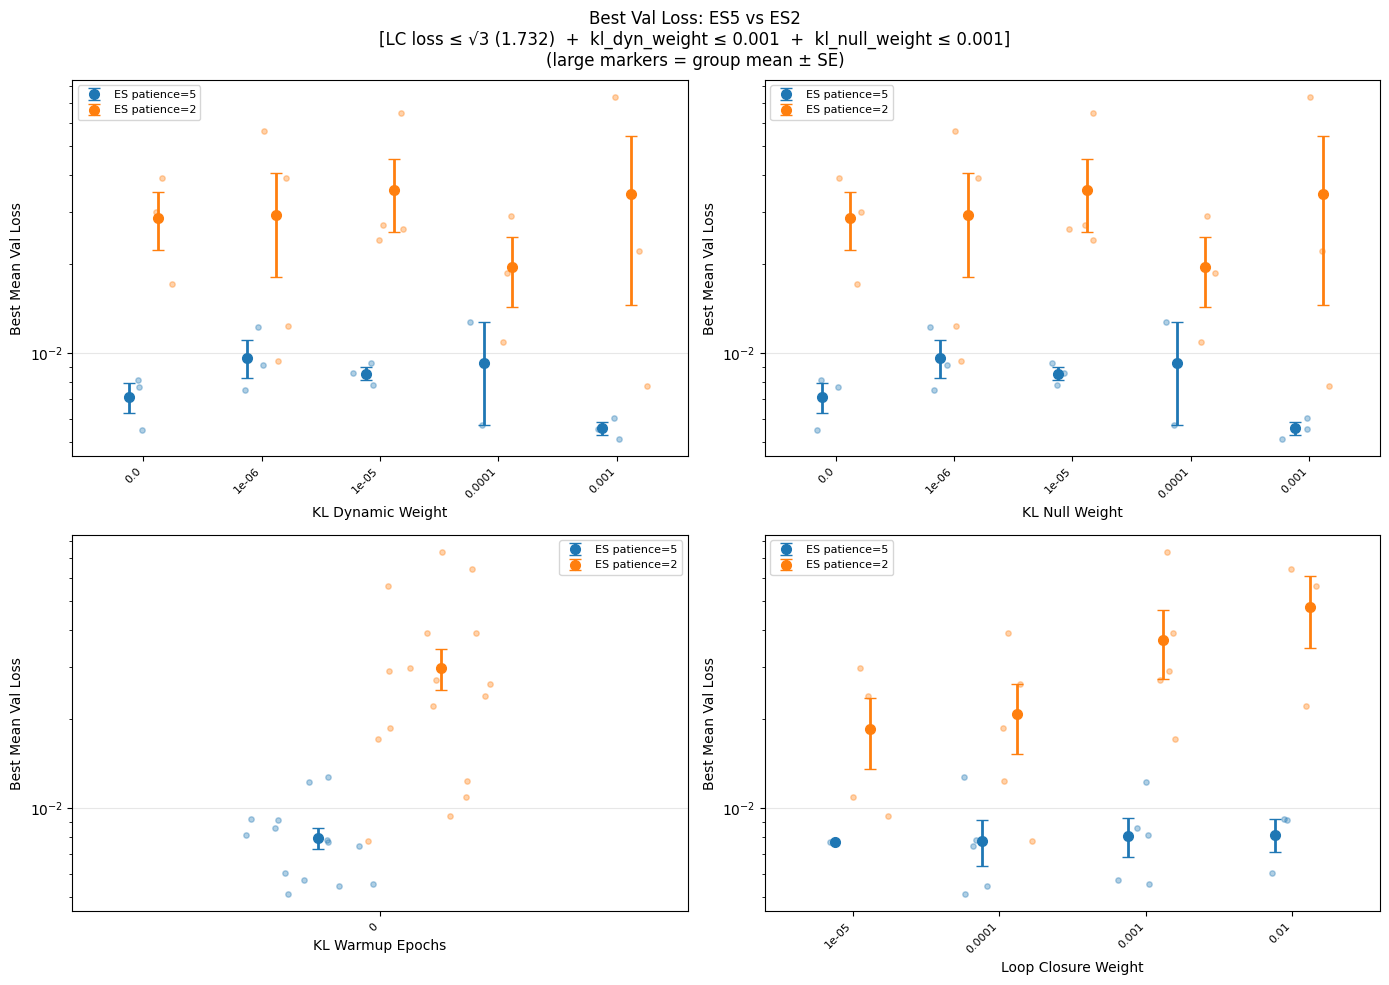

In [41]:
# ================================================================
# Same plot as above, but additionally filtered to
# kl_dyn_weight <= KL_DYN_WEIGHT_THRESHOLD
# kl_null_weight <= KL_NULL_WEIGHT_THRESHOLD
KL_DYN_WEIGHT_THRESHOLD = 0.001
KL_NULL_WEIGHT_THRESHOLD = 0.001
df_p5_kld = df_p5[(df_p5['kl_dyn_weight'] <= KL_DYN_WEIGHT_THRESHOLD) & (df_p5['kl_null_weight'] <= KL_NULL_WEIGHT_THRESHOLD)]
df_p2_kld = df_p2[(df_p2['kl_dyn_weight'] <= KL_DYN_WEIGHT_THRESHOLD) & (df_p2['kl_null_weight'] <= KL_NULL_WEIGHT_THRESHOLD)]
print(f'After kl_dyn_weight ≤ {KL_DYN_WEIGHT_THRESHOLD} + kl_null_weight ≤ {KL_NULL_WEIGHT_THRESHOLD} filter:')
print(f'  ES5: {len(df_p5_kld)} / {len(df_p5)} runs kept')
print(f'  ES2: {len(df_p2_kld)} / {len(df_p2)} runs kept')
for _es_label, _src_df, _loss_col in [('ES5', df_p5_kld, 'best_val_loss_p5'), ('ES2', df_p2_kld, 'best_val_loss_p2')]:
    print(f'\n{_es_label} — mean val loss by kl_warmup_epochs:')
    for we in sorted(_src_df['kl_warmup_epochs'].unique()):
        _vals = _src_df.loc[_src_df['kl_warmup_epochs'] == we, _loss_col].dropna()
        print(f'  warmup={we:>4g}: mean={_vals.mean():.4f}  n={len(_vals)}')
_fig, _axes = plt.subplots(2, 2, figsize=(14, 10))
_params = [('kl_dyn_weight', 'KL Dynamic Weight'), ('kl_null_weight', 'KL Null Weight'), ('kl_warmup_epochs', 'KL Warmup Epochs'), ('loop_closure_weight', 'Loop Closure Weight')]
_rng2 = np.random.default_rng(42)
for _ax, (_col, _label) in zip(_axes.flat, _params):
# Print warmup epoch comparison for reference
    _categories = sorted(set(df_p5_kld[_col].unique()) | set(df_p2_kld[_col].unique()))
    _cat_to_pos = {c: _i for _i, c in enumerate(_categories)}
    _n_cats = len(_categories)
    for _src_df, _offset, _loss_col, _color, _es_label in [(df_p5_kld, -0.12, 'best_val_loss_p5', 'C0', 'ES patience=5'), (df_p2_kld, 0.12, 'best_val_loss_p2', 'C1', 'ES patience=2')]:
        _positions = np.array([_cat_to_pos[v] for v in _src_df[_col]])
        _jitter = _rng2.uniform(-0.15, 0.15, size=len(_src_df))
        _ax.scatter(_positions + _jitter + _offset, _src_df[_loss_col], alpha=0.35, s=15, color=_color, zorder=2)
        _first = True
        for _i, _cat in enumerate(_categories):
            _mask = _src_df[_col] == _cat
            _vals = _src_df.loc[_mask, _loss_col].dropna()
            if len(_vals) == 0:
                continue
            _mean = _vals.mean()
            _se = _vals.sem()
            _ax.errorbar(_i + _offset, _mean, yerr=_se, fmt='o', color=_color, markersize=7, capsize=4, linewidth=2, zorder=3, label=_es_label if _first else None)
            _first = False
    _ax.set_xticks(range(_n_cats))
    _ax.set_xticklabels([str(c) for c in _categories], rotation=45, ha='right', fontsize=8)
    _ax.set_xlim(-0.6, _n_cats - 0.4)
    _ax.set_xlabel(_label)
    _ax.set_ylabel('Best Mean Val Loss')  # Only show categories present in the filtered data (union of both ES sets)
    _ax.set_yscale('log')
    _ax.legend(fontsize=8)
    _ax.grid(True, axis='y', alpha=0.3)
_filter_str = f'LC loss ≤ √3 ({LC_LOSS_THRESHOLD:.3f})' if LC_LOSS_FILTER else 'no LC loss filter'
_fig.suptitle(f'Best Val Loss: ES5 vs ES2\n[{_filter_str}  +  kl_dyn_weight ≤ {KL_DYN_WEIGHT_THRESHOLD}  +  kl_null_weight ≤ {KL_NULL_WEIGHT_THRESHOLD}]\n(large markers = group mean ± SE)', fontsize=12)
_fig.tight_layout()
plt.show()

## 7. Loss Curve Choppiness vs Hyperparameters

Three metrics quantify how non-monotone the val loss curve is over the full training run:

| Metric | Definition | Interpretation |
|---|---|---|
| **Normalized Total Variation (NTV)** | `Σ|ΔL| / (L_first − L_best)` | 1.0 = perfectly monotone; higher = more backtracking relative to net improvement |
| **Fraction non-improving steps** | fraction of epochs where `L(t) ≥ L(t−1)` | 0 = always improving; ~0.5 = random walk |
| **Mean abs change / mean loss** | `mean(|ΔL|) / mean(L)` | Scale-free per-epoch roughness |

A choppy curve is the reason ES5 outperforms ES2: the model needs patience to wait through temporary upswings.

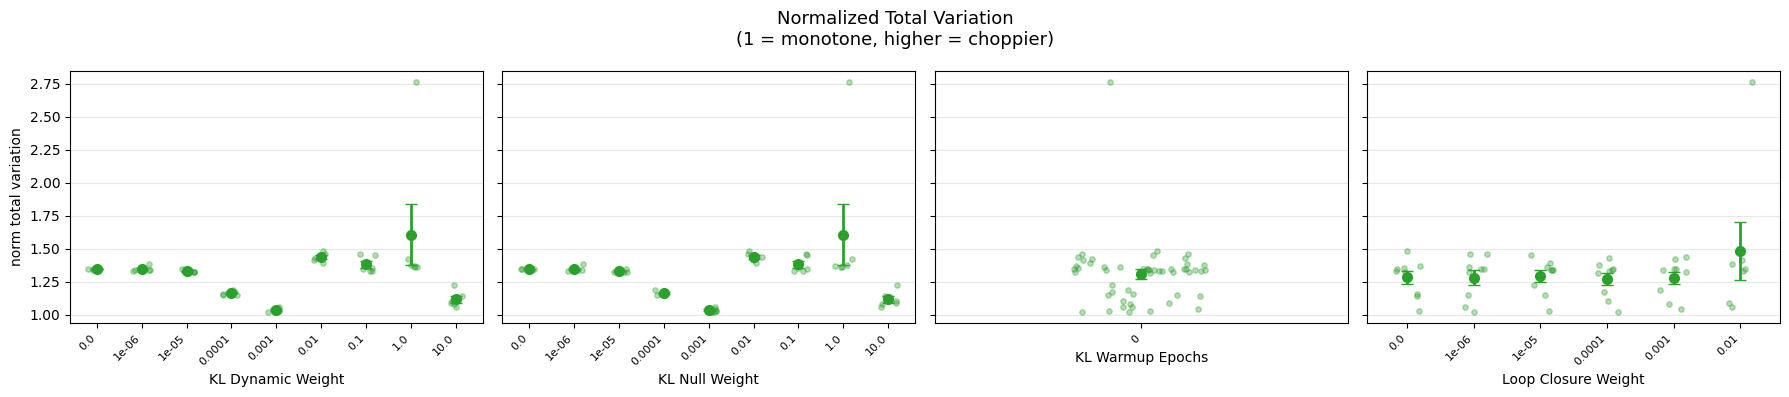

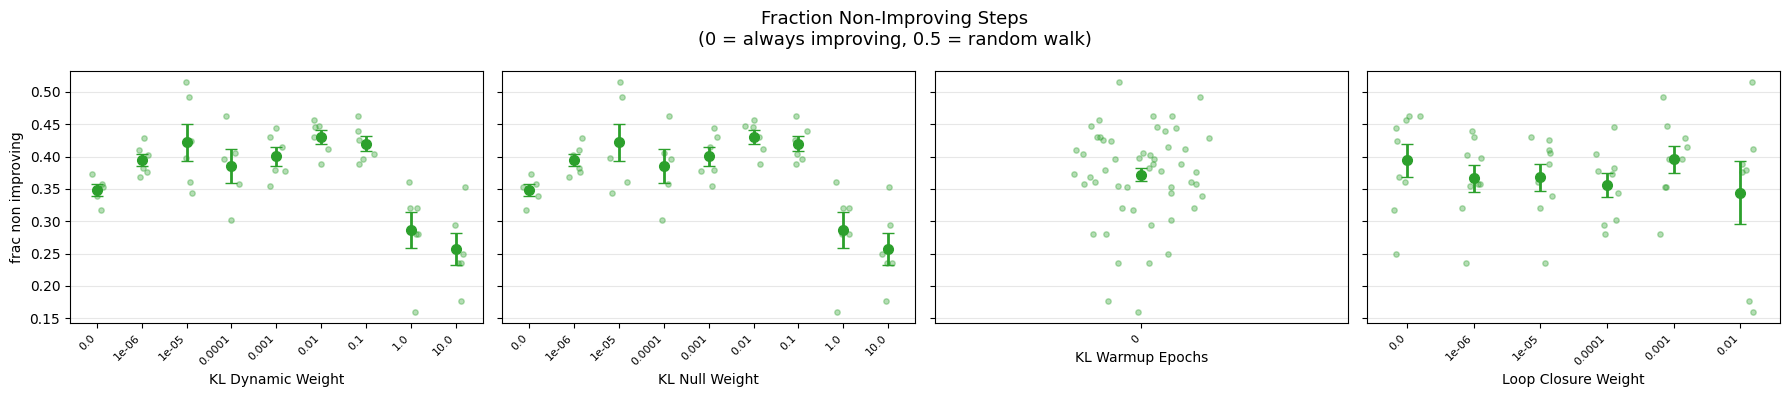

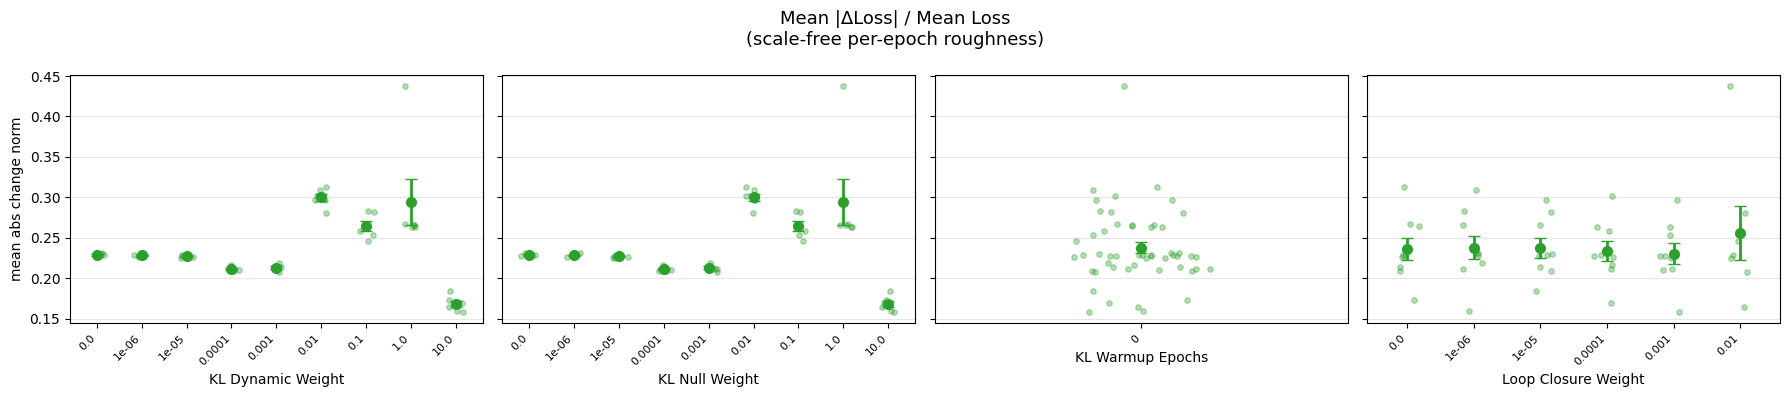

In [42]:
choppiness_metrics = [('norm_total_variation', 'Normalized Total Variation\n(1 = monotone, higher = choppier)'), ('frac_non_improving', 'Fraction Non-Improving Steps\n(0 = always improving, 0.5 = random walk)'), ('mean_abs_change_norm', 'Mean |ΔLoss| / Mean Loss\n(scale-free per-epoch roughness)')]
hparams = [('kl_dyn_weight', 'KL Dynamic Weight'), ('kl_null_weight', 'KL Null Weight'), ('kl_warmup_epochs', 'KL Warmup Epochs'), ('loop_closure_weight', 'Loop Closure Weight')]
_rng2 = np.random.default_rng(0)
for chop_col, chop_label in choppiness_metrics:
    _fig, _axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
    _fig.suptitle(chop_label, fontsize=13)
    for _ax, (_col, _label) in zip(_axes, hparams):
        _categories = sorted(df[_col].unique())
        _cat_to_pos = {c: _i for _i, c in enumerate(_categories)}
        _n_cats = len(_categories)
        valid = df[chop_col].notna()
        _positions = np.array([_cat_to_pos[v] for v in df.loc[valid, _col]])
        _jitter = _rng2.uniform(-0.2, 0.2, size=valid.sum())
        _ax.scatter(_positions + _jitter, df.loc[valid, chop_col], alpha=0.35, s=15, color='C2', zorder=2)
        for _i, _cat in enumerate(_categories):
            _mask = valid & (df[_col] == _cat)
            _vals = df.loc[_mask, chop_col].dropna()
            if len(_vals) == 0:
                continue
            _ax.errorbar(_i, _vals.mean(), yerr=_vals.sem(), fmt='o', color='C2', markersize=7, capsize=4, linewidth=2, zorder=3)
        _ax.set_xticks(range(_n_cats))
        _ax.set_xticklabels([str(c) for c in _categories], rotation=45, ha='right', fontsize=8)
        _ax.set_xlim(-0.6, _n_cats - 0.4)
        _ax.set_xlabel(_label)
        _ax.grid(True, axis='y', alpha=0.3)
    _axes[0].set_ylabel(chop_col.replace('_', ' '))
    _fig.tight_layout()
    plt.show()  # Group mean ± SE

In [43]:
df_lc_valid = df[df['lc_loss_at_best_p5'] <= math.sqrt(3)]
_best_run = df_lc_valid.loc[df_lc_valid['best_val_loss_p5'].idxmin()]

In [44]:
df_lc_valid_1 = df[df['lc_loss_at_best_p5'] <= math.sqrt(3)]
ref_row = df_lc_valid_1.loc[df_lc_valid_1['best_val_loss_p5'].idxmin()]
_mask = (df['kl_null_weight'] == ref_row['kl_null_weight']) & (df['kl_dyn_weight'] == ref_row['kl_dyn_weight']) & (df['loop_closure_weight'] == ref_row['loop_closure_weight']) & (df['kl_warmup_epochs'] == 10)
matching_runs = df[_mask]
if len(matching_runs) == 0:
    best_run_kl_warmup = None
else:
    best_run_kl_warmup = matching_runs.loc[matching_runs['best_val_loss_p5'].idxmin()]

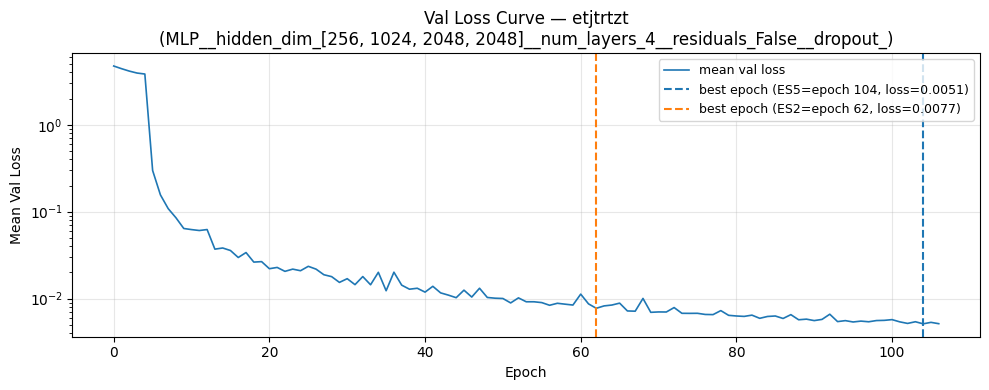

In [45]:
_best_row = df_lc_valid_1.loc[df_lc_valid_1['best_val_loss_p5'].idxmin()]
best_run_id = _best_row['run_id']
_best_run = next((r for r in all_runs if r.id == best_run_id))
_history = list(_best_run.scan_history(keys=['mean val loss', 'epoch', '_step'], page_size=10000))
rows = [(_row['epoch'], float(_row['mean val loss'])) for _row in _history if _row.get('mean val loss') is not None and _row.get('epoch') is not None]
epochs_x, val_losses_best = zip(*rows)
epoch_p5 = epochs_x[int(_best_row['best_epoch_p5'])]
epoch_p2 = epochs_x[int(_best_row['best_epoch_p2'])]
_fig, _ax = plt.subplots(figsize=(10, 4))
_ax.plot(epochs_x, val_losses_best, lw=1.2, color='C0', label='mean val loss')
_ax.axvline(epoch_p5, color='C0', linestyle='--', lw=1.5, label=f'best epoch (ES5=epoch {epoch_p5}, loss={_best_row["best_val_loss_p5"]:.4f})')
_ax.axvline(epoch_p2, color='C1', linestyle='--', lw=1.5, label=f'best epoch (ES2=epoch {epoch_p2}, loss={_best_row["best_val_loss_p2"]:.4f})')
_ax.set_xlabel('Epoch')
_ax.set_ylabel('Mean Val Loss')
_ax.set_yscale('log')
_ax.set_title(f'Val Loss Curve — {best_run_id}\n({_best_row["run_name"][:80]})')
_ax.legend(fontsize=9)
_ax.grid(True, alpha=0.3)
_fig.tight_layout()
plt.show()

## Trajectory Val Loss: Early Epoch vs Best Epoch (ES patience=5)

For each run with early stopping patience = 5, pull the `trajectory val_loss` history from W&B and scatter-plot the value at an early epoch (y) against the best value across all epochs (x).

Runs with trajectory val_loss at epoch 15: 52
Confusion matrix (rows: at_epoch [best, worst], cols: best [best, worst]):
[[20  6]
 [ 6 20]]
Labels:
[[best in both, bad x], [bad y, worst in both]]
Sensitivity (True Positive Rate): 0.769
Specificity (True Negative Rate): 0.769


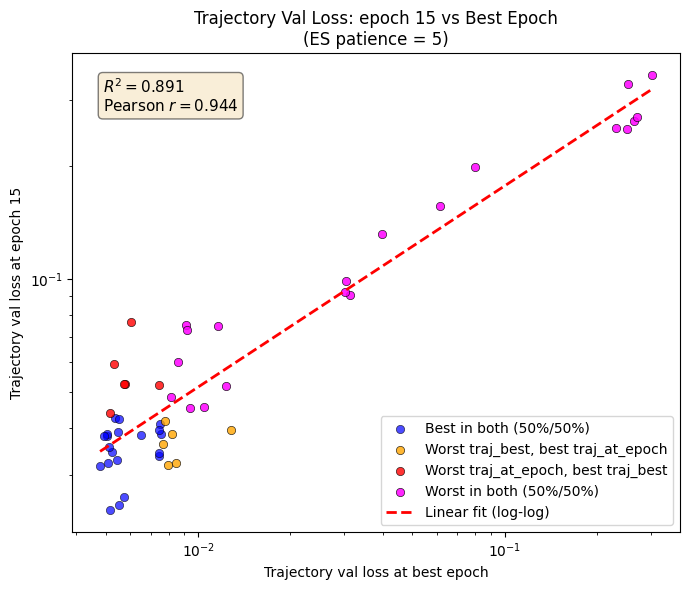

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix
import scipy.stats
USE_LOGLOG = True
COMPARE_EPOCH = 15
# COMPARE_EPOCH = [16, 17, 18, 19, 20]
if isinstance(COMPARE_EPOCH, (list, tuple, np.ndarray)):
    compare_epochs = [int(e) for e in COMPARE_EPOCH]
else:
    compare_epochs = [int(COMPARE_EPOCH)]
compare_epoch_label = (
    f"mean over epochs {compare_epochs}"
    if len(compare_epochs) > 1
    else f"epoch {compare_epochs[0]}"
)
traj_at_epoch = []
traj_best = []
for _, _row in df.iterrows():
    hist = _row['traj_val_loss_history']
    if _row['es_patience'] != 5:
        continue
    if any(e < 0 or len(hist) <= e for e in compare_epochs):
        continue
    vals_at_epochs = [hist[e] for e in compare_epochs]
    val_at_epoch = float(np.mean(vals_at_epochs))
    finite = [l for l in hist if math.isfinite(l)]
    if not finite or not all(math.isfinite(v) for v in vals_at_epochs):
        continue
    traj_at_epoch.append(val_at_epoch)
    traj_best.append(min(finite))
print(f'Runs with trajectory val_loss at {compare_epoch_label}: {len(traj_best)}')
x_raw = np.array(traj_best)
y_raw = np.array(traj_at_epoch)
if USE_LOGLOG:
    _mask = (x_raw > 0) & (y_raw > 0)
    x_plot = x_raw[_mask]
    y_plot = y_raw[_mask]
    x = np.log10(x_plot).reshape(-1, 1)
    y = np.log10(y_plot)
else:
    _mask = np.ones_like(x_raw, dtype=bool)
    x_plot = x_raw
    y_plot = y_raw
    x = x_plot.reshape(-1, 1)
    y = y_plot
n_points = len(y_plot)
if n_points > 0:
    median_y = np.median(y_plot)
    median_x = np.median(x_plot)
    worst_y = y_plot >= median_y
    worst_x = x_plot >= median_x
    better_y = ~worst_y
    better_x = ~worst_x
else:
    worst_y = np.array([], dtype=bool)
    worst_x = np.array([], dtype=bool)
    better_y = np.array([], dtype=bool)
    better_x = np.array([], dtype=bool)
mask_best_both = better_x & better_y
mask_bad_x = worst_x & better_y
mask_bad_y = better_x & worst_y
mask_worst_both = worst_x & worst_y
cm = confusion_matrix(np.where(worst_y, 1, 0), np.where(worst_x, 1, 0))
print('Confusion matrix (rows: at_epoch [best, worst], cols: best [best, worst]):')
print(cm)
print('Labels:')
print('[[best in both, bad x], [bad y, worst in both]]')
if cm.shape == (2, 2):
    TP = cm[1, 1]
    FN = cm[1, 0]
    TN = cm[0, 0]
    FP = cm[0, 1]
    sensitivity = TP / (TP + FN) if TP + FN != 0 else float('nan')
    specificity = TN / (TN + FP) if TN + FP != 0 else float('nan')
    print(f'Sensitivity (True Positive Rate): {sensitivity:.3f}')
    print(f'Specificity (True Negative Rate): {specificity:.3f}')
_fig, _ax = plt.subplots(figsize=(7, 6))
if USE_LOGLOG:
    _ax.scatter(x_plot[mask_best_both], y_plot[mask_best_both], alpha=0.7, edgecolors='k', linewidths=0.5, color='blue', label='Best in both (50%/50%)')
    _ax.scatter(x_plot[mask_bad_x], y_plot[mask_bad_x], alpha=0.8, edgecolors='k', linewidths=0.5, color='orange', label='Worst traj_best, best traj_at_epoch')
    _ax.scatter(x_plot[mask_bad_y], y_plot[mask_bad_y], alpha=0.8, edgecolors='k', linewidths=0.5, color='red', label='Worst traj_at_epoch, best traj_best')
    _ax.scatter(x_plot[mask_worst_both], y_plot[mask_worst_both], alpha=0.85, edgecolors='k', linewidths=0.5, color='magenta', label='Worst in both (50%/50%)')
else:
    _ax.scatter(x_plot[mask_best_both], y_plot[mask_best_both], alpha=0.7, edgecolors='k', linewidths=0.5, color='blue', label='Best in both (50%/50%)')
    _ax.scatter(x_plot[mask_bad_x], y_plot[mask_bad_x], alpha=0.8, edgecolors='k', linewidths=0.5, color='orange', label='Worst traj_best, best traj_at_epoch')
    _ax.scatter(x_plot[mask_bad_y], y_plot[mask_bad_y], alpha=0.8, edgecolors='k', linewidths=0.5, color='red', label='Worst traj_at_epoch, best traj_best')
    _ax.scatter(x_plot[mask_worst_both], y_plot[mask_worst_both], alpha=0.85, edgecolors='k', linewidths=0.5, color='magenta', label='Worst in both (50%/50%)')
reg = LinearRegression().fit(x, y)
y_pred = reg.predict(x)
r2 = r2_score(y, y_pred)
if USE_LOGLOG:
    corr_coef, corr_p = scipy.stats.pearsonr(x.flatten(), y)
else:
    corr_coef, corr_p = scipy.stats.pearsonr(x_raw, y_raw)
if USE_LOGLOG:
    xlin_range = np.linspace(x_plot.min(), x_plot.max(), 200)
    xlog_range = np.log10(xlin_range)
    ylog_pred = reg.predict(xlog_range.reshape(-1, 1))
    ylin_pred = 10 ** ylog_pred
    _ax.plot(xlin_range, ylin_pred, color='red', linestyle='--', lw=2, label='Linear fit (log-log)')
else:
    x_range = np.linspace(x_plot.min(), x_plot.max(), 200).reshape(-1, 1)
    _ax.plot(x_range, reg.predict(x_range), color='red', linestyle='--', lw=2, label='Linear fit')
stats_text = f'$R^2={r2:.3f}$\nPearson $r={corr_coef:.3f}$'
_ax.annotate(stats_text, xy=(0.05, 0.95), xycoords='axes fraction', va='top', ha='left', fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
_ax.set_xlabel('Trajectory val loss at best epoch')
_ax.set_ylabel(f'Trajectory val loss at {compare_epoch_label}')
_ax.set_title(f'Trajectory Val Loss: {compare_epoch_label} vs Best Epoch\n(ES patience = 5)')
_ax.legend()
if USE_LOGLOG:
    _ax.set_xscale('log')
    _ax.set_yscale('log')
_fig.tight_layout()
plt.show()

## Compare cosine vs tf scheduling

In [ ]:
COMPARE_GROUP = 'sweep_from_scratch_spline_coupling_lc_1vals__klNnull__klD0.0001__te0.0_enc_warmup_5_vaetrue'
COMPARE_RUN_ID = 'cvmwmr96'
COMPARE_RUN_ID_KL_WARMUP = best_run_kl_warmup['run_id']
compare_run = api.run(f'{WANDB_PROJECT_PATH}/{COMPARE_RUN_ID}')
compare_run_kl_warmup = api.run(f'{WANDB_PROJECT_PATH}/{COMPARE_RUN_ID_KL_WARMUP}')

def fetch_val_loss_curve(run):
    _history = list(run.scan_history(keys=['mean val loss', 'epoch'], page_size=10000))
    rows = [(_row['epoch'], float(_row['mean val loss'])) for _row in _history if _row.get('mean val loss') is not None and _row.get('epoch') is not None]
    if not rows:
        return ([], [])
    epochs_x, losses = zip(*rows)
    return (list(epochs_x), list(losses))
_best_row = df_lc_valid_1.loc[df_lc_valid_1['best_val_loss_p5'].idxmin()]
_best_run = next((r for r in all_runs if r.id == _best_row['run_id']))
epochs_best, losses_best = fetch_val_loss_curve(_best_run)
epoch_p5_best = epochs_best[int(_best_row['best_epoch_p5'])]
epochs_cmp, losses_cmp = fetch_val_loss_curve(compare_run)
epochs_cmp_kl_warmup, losses_cmp_kl_warmup = fetch_val_loss_curve(compare_run_kl_warmup)
epoch_p5_cmp_kl_warmup = epochs_cmp_kl_warmup[int(best_run_kl_warmup['best_epoch_p5'])]
_fig, _ax = plt.subplots(figsize=(11, 5))
_ax.plot(epochs_best, losses_best, lw=1.2, color='C0', label=f'best run ({_best_row["run_id"]})')
_ax.axvline(epoch_p5_best, color='C0', linestyle='--', lw=1.2, label=f'best ckpt epoch {epoch_p5_best} (loss={_best_row["best_val_loss_p5"]:.4f})')
_ax.plot(epochs_cmp, losses_cmp, lw=1.2, color='C1', label=f'compare run ({COMPARE_RUN_ID})')
_ax.plot(epochs_cmp_kl_warmup, losses_cmp_kl_warmup, lw=1.2, color='C2', label=f'compare run (KL warmup=10) ({COMPARE_RUN_ID_KL_WARMUP})')
_ax.axvline(epoch_p5_cmp_kl_warmup, color='C2', linestyle='--', lw=1.2, label=f'best ckpt epoch {epoch_p5_cmp_kl_warmup} (loss={_best_row["best_val_loss_p5"]:.4f})')
_ax.set_xlabel('Epoch')
_ax.set_ylabel('Mean Val Loss')
_ax.set_yscale('log')
_ax.set_title('Val Loss Curve Comparison')
_ax.legend(fontsize=9)
_ax.grid(True, alpha=0.3)
_fig.tight_layout()
plt.show()

In [ ]:
from JacobianODE.jacobians.run_analytics import run_analytics

run_analytics(
    wandb_entity="JacobianODE",
    wandb_project=WANDB_PROJECT,
    wandb_group=WANDB_GROUP,
    run_id=best_run_id,
    save_dir="/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/latent_jac_runs",
    true_lyapunov=[0.91, 0.0, -14.57],
    output=["show", "html"],   # or "save", or "return"
    # output="show",
    output_dir="../reports",
)